In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
# from sklearn.metrics import calinski_harabasz_score

import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('../data/students_cleaned.csv').dropna()

# Define columns to drop
cols_to_drop = ['region_East Midlands Region', 'region_Ireland', 'region_London Region', 
                'region_North Region', 'region_North Western Region', 'region_Scotland', 
                'region_South East Region', 'region_South Region', 'region_South West Region', 
                'region_Wales', 'region_West Midlands Region', 'region_Yorkshire Region', 
                'code_module_y_BBB', 'code_module_y_CCC', 'code_module_y_DDD', 
                'code_module_y_EEE', 'code_module_y_FFF', 'code_module_y_GGG']

# Only drop columns that exist
data = data.drop(columns=[col for col in cols_to_drop if col in data.columns])

KeyError: "['region_East Midlands Region', 'region_Ireland', 'region_London Region', 'region_North Region', 'region_North Western Region', 'region_Scotland', 'region_South East Region', 'region_South Region', 'region_South West Region', 'region_Wales', 'region_West Midlands Region', 'region_Yorkshire Region', 'code_module_y_BBB', 'code_module_y_CCC', 'code_module_y_DDD', 'code_module_y_EEE', 'code_module_y_FFF', 'code_module_y_GGG'] not found in axis"

In [ ]:
training_data, test_data = train_test_split(data, test_size=0.2, random_state=42)
# training_data, val_data = train_test_split(training_val, test_size=0.2, random_state=42)

In [ ]:
feature_cols = [c for c in training_data.columns if c != "final_result"]
train_X = training_data[feature_cols]
# val_X = val_data[feature_cols]

In [ ]:
eps_values = [round(x, 2) for x in np.linspace(0.5, 4, num=6)]
min_samples_values = range(5, 15, 5)

results = []
index = 0
for eps in eps_values:
    for min_samples in min_samples_values:
        clusterer = make_pipeline(DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean'))
        
        # Fit on training set only
        train_labels = clusterer.fit_predict(train_X)
        n_clusters_train = len(set(train_labels)) - (1 if -1 in train_labels else 0)
        n_noise_train = list(train_labels).count(-1)
        

        # scan on validation set       
        silhouette_score_val = silhouette_score(train_X, train_labels) if n_clusters_train > 1 else -1
        davies_bouldin_score_val = davies_bouldin_score(train_X, train_labels) if n_clusters_train > 1 else -1
        # calinski_harabasz_score_val = calinski_harabasz_score(train_X, train_labels) if n_clusters
        
        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters_train": n_clusters_train,
            "n_noise_train": n_noise_train,
            "silhouette_score_val": silhouette_score_val,
            "davies_bouldin_score_val": davies_bouldin_score_val
        })
        if 10 < n_clusters_train < 20:
            print(f"Tested eps={eps}, min_samples={min_samples} -> {n_clusters_train} clusters (train)")
        print(f"Completed {((index+1)/(len(eps_values)*len(min_samples_values)))*100}%")
        index += 1
results_df = pd.DataFrame(results)


Completed 5.6%
Completed 11.1%
Completed 16.7%
Completed 22.2%


: 

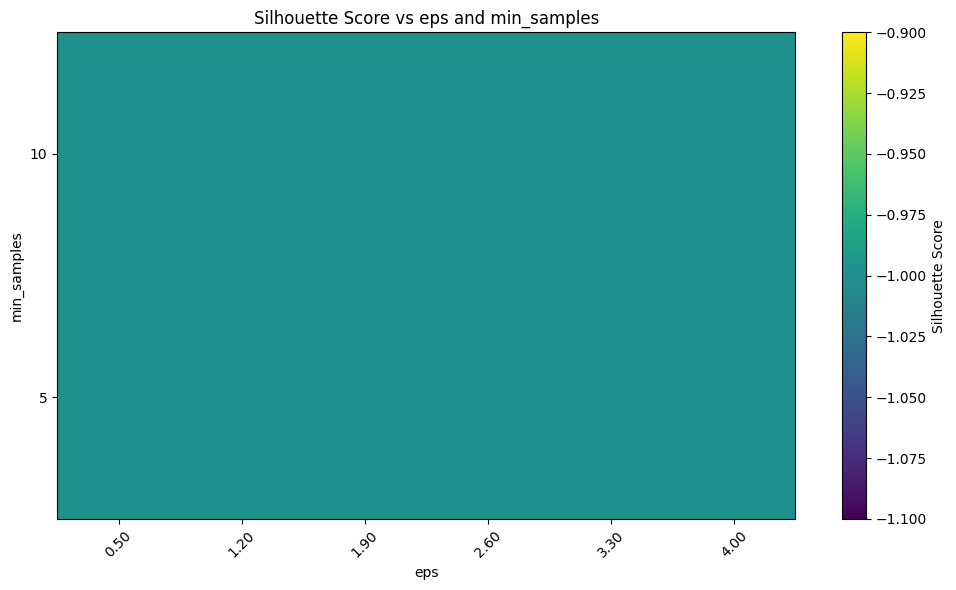

In [ ]:
pivot_silhouette = results_df.pivot_table(
    values='silhouette_score_val',
    index='min_samples',
    columns='eps'
)

plt.figure(figsize=(10, 6))
plt.imshow(pivot_silhouette, aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(label='Silhouette Score')
plt.xlabel('eps')
plt.ylabel('min_samples')
plt.title('Silhouette Score vs eps and min_samples')
plt.xticks(range(len(pivot_silhouette.columns)), [f'{x:.2f}' for x in pivot_silhouette.columns], rotation=45)
plt.yticks(range(len(pivot_silhouette.index)), pivot_silhouette.index)
plt.tight_layout()
plt.show()

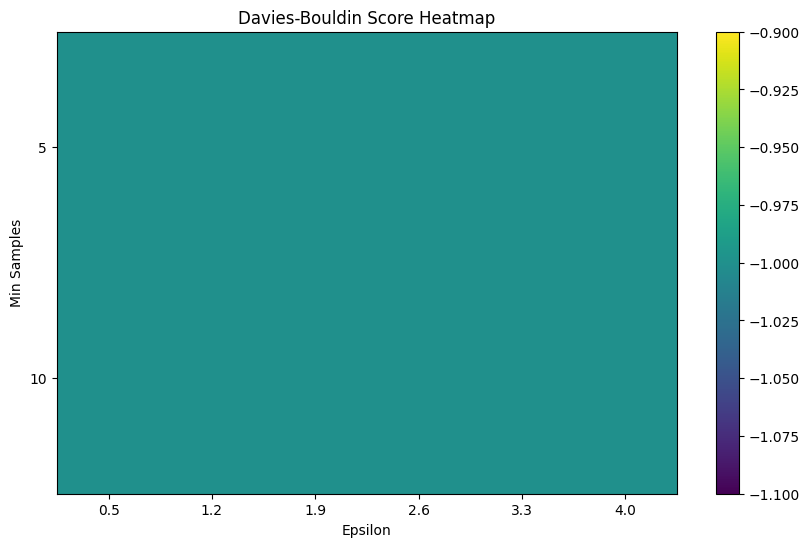

In [ ]:
pivot_davies = results_df.pivot_table(index='min_samples', columns='eps', values='davies_bouldin_score_val')

plt.figure(figsize=(10, 6))
plt.imshow(pivot_davies, cmap='viridis', aspect='auto')
plt.bar_label = plt.colorbar()
plt.title('Davies-Bouldin Score Heatmap')
plt.xlabel('Epsilon')
plt.ylabel('Min Samples')
plt.xticks(ticks=np.arange(len(pivot_davies.columns)), labels=pivot_davies.columns)
plt.yticks(ticks=np.arange(len(pivot_davies.index)), labels=pivot_davies.index)
plt.show()

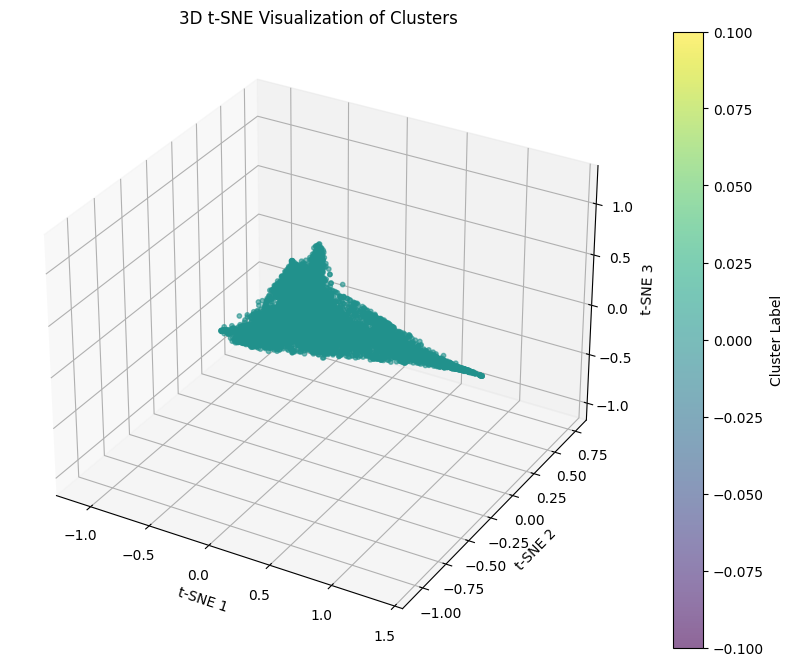

In [ ]:
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

# Apply t-SNE with 3 components
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=250)
tsne_results = tsne.fit_transform(train_X)

# Create a 3D scatter plot

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='2d')

scatter = ax.scatter(tsne_results[:, 0], tsne_results[:, 1], tsne_results[:, 2], 
                     c=train_labels, cmap='viridis', s=10, alpha=0.6)

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('3D t-SNE Visualization of Clusters')
plt.colorbar(scatter, ax=ax, label='Cluster Label')
plt.show()